
Our dataset consists of clinical data from patients who entered the hospital complaining of chest pain ("angina") during exercise.  The information collected includes:

* `age` : Age of the patient

* `sex` : Sex of the patient

* `cp` : Chest Pain type

    + Value 0: asymptomatic
    + Value 1: typical angina
    + Value 2: atypical angina
    + Value 3: non-anginal pain
   
    
* `trtbps` : resting blood pressure (in mm Hg)

* `chol` : cholesterol in mg/dl fetched via BMI sensor

* `restecg` : resting electrocardiographic results

    + Value 0: normal
    + Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    + Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* `thalach` : maximum heart rate achieved during exercise

* `output` : the doctor's diagnosis of whether the patient is at risk for a heart attack
    + 0 = not at risk of heart attack
    + 1 = at risk of heart attack

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.metrics import *
from sklearn.compose import *
from sklearn.tree import *
from sklearn.svm import *
import sklearn.discriminant_analysis

In [4]:
ha = pd.read_csv("heart_attack.csv")
ha.head()

,age,sex,cp,trtbps,chol,restecg,thalach,output
0,63,1,3,145,233,0,150,1
1,37,1,2,130,250,1,187,1
2,56,1,1,120,236,1,178,1
3,57,0,0,120,354,1,163,1
4,57,1,0,140,192,1,148,1


## Q1: Natural Multiclass Models

Fit a multiclass KNN, Decision Tree, and LDA for the heart disease data; this time predicting the type of chest pain (categories 0 - 3) that a patient experiences.  For the decision tree, plot the fitted tree, and interpret the first couple splits.


In [5]:
X = ha[["age","chol","trtbps"]]
y = ha["cp"]

cv = 5
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=321)

In [6]:
ct_knn = ColumnTransformer([
    ("standardize", StandardScaler(), make_column_selector(dtype_include=np.number))
])

pipeline_knn = Pipeline([
    ("ct", ct_knn),
    ("knn", KNeighborsClassifier())
])

paramGrid = {"knn__n_neighbors": range(1,11)}
search = GridSearchCV(pipeline_knn, paramGrid,cv=cv,scoring="accuracy")

In [7]:
KNN_fit = search.fit(X_train, y_train)
pd.DataFrame(search.cv_results_).sort_values("rank_test_score")[["param_knn__n_neighbors","mean_test_score","rank_test_score"]]

,param_knn__n_neighbors,mean_test_score,rank_test_score
6,7,0.486910,1
8,9,0.465857,2
9,10,0.455466,3
1,2,0.449933,4
7,8,0.444939,5
5,6,0.434683,6
3,4,0.429285,7
4,5,0.424157,8
2,3,0.413360,9
0,1,0.356140,10


In [8]:
predictions_knn = KNN_fit.predict(X_test)

cm = confusion_matrix(y_test, predictions_knn)

accuracy_KNN = accuracy_score(y_test, predictions_knn)
recall_KNN = recall_score(y_test, predictions_knn, average='weighted')
precision_KNN = precision_score(y_test, predictions_knn, average='weighted')
f1_KNN = f1_score(y_test, predictions_knn, average='weighted')

print("KNN")
print(f"Accuracy: {accuracy_KNN}")
print(f"Recall: {recall_KNN}")
print(f"Precision: {precision_KNN}")
print(f"F1 Score: {f1_KNN}")

KNN
Accuracy: 0.32926829268292684
Recall: 0.32926829268292684
Precision: 0.28398527381500227
F1 Score: 0.291019955654102


In [9]:
prediction_prob = KNN_fit.predict_proba(X_test)
roc_KNN = roc_auc_score(y_test, prediction_prob, multi_class='ovr', average='weighted')
print(f"The optimal KNN model produces a ROC_AUC score of {roc_KNN}")

The optimal KNN model produces a ROC_AUC score of 0.45558703855184157


Decision Tree

In [10]:
ct_dt = ColumnTransformer([
    ("standardize", StandardScaler(), make_column_selector(dtype_include=np.number))
])

pipeline_dt = Pipeline([
    ("ct", ct_dt),
    ("model", DecisionTreeClassifier(max_depth=2))
])


dt_Model = pipeline_dt.fit(X_train, y_train)

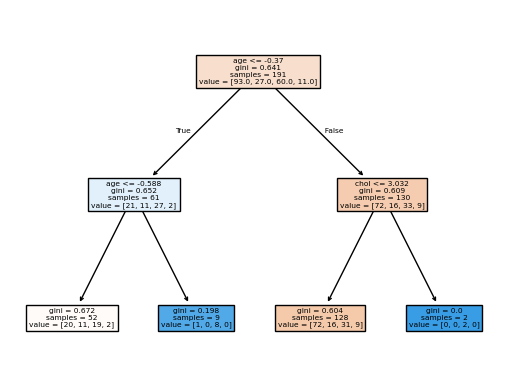

<Figure size 1000x1000 with 0 Axes>

In [11]:
plot_tree(dt_Model.named_steps["model"], feature_names=["age", "chol", "trtbps"], filled=True)
plt.figure(figsize=(10,10))
plt.show()

In [12]:
predictions_dt = dt_Model.predict(X_test)

cm = confusion_matrix(y_test, predictions_dt)

accuracy_DT = accuracy_score(y_test, predictions_dt)
recall_DT = recall_score(y_test, predictions_dt, average='weighted')
precision_DT = precision_score(y_test, predictions_dt, average='weighted')
f1_DT = f1_score(y_test, predictions_dt, average='weighted')

print(f"Accuracy: {accuracy_DT}")
print(f"Recall: {recall_DT}")
print(f"Precision: {precision_DT}")
print(f"F1 Score: {f1_DT}")

Accuracy: 0.4024390243902439
Recall: 0.4024390243902439
Precision: 0.2495934959349594
F1 Score: 0.2771618625277162


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
testPredictionProbs = dt_Model.predict_proba(X_test)
roc_DT = roc_auc_score(y_test, testPredictionProbs, multi_class='ovr', average='weighted')
print(f"The DT model produces a ROC_AUC score of {roc_DT}")

The DT model produces a ROC_AUC score of 0.5829539538129549


LDA

In [14]:
ct_lda = ColumnTransformer([
    ("standardize", StandardScaler(), make_column_selector(dtype_include=np.number))
])

pipeline_lda = Pipeline([
    ("ct", ct_dt),
    ('lda', sklearn.discriminant_analysis.LinearDiscriminantAnalysis())
])


lda_Model = pipeline_lda.fit(X_train, y_train)

In [15]:
predictions_lda = lda_Model.predict(X_test)

cm = confusion_matrix(y_test, predictions_lda)

accuracy_LDA = accuracy_score(y_test, predictions_lda)
recall_LDA = recall_score(y_test, predictions_lda, average='weighted')
precision_LDA = precision_score(y_test, predictions_lda, average='weighted')
f1_LDA = f1_score(y_test, predictions_lda, average='weighted')

print(f"Accuracy: {accuracy_LDA}")
print(f"Recall: {recall_LDA}")
print(f"Precision: {precision_LDA}")
print(f"F1 Score: {f1_LDA}")

Accuracy: 0.4146341463414634
Recall: 0.4146341463414634
Precision: 0.2643771922669059
F1 Score: 0.3065059044255601


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
testPredictionProbs = lda_Model.predict_proba(X_test)
roc_LDA = roc_auc_score(y_test, testPredictionProbs, multi_class='ovr', average='weighted')
print(f"The LDA model produces a ROC_AUC score of {roc_LDA}")

The LDA model produces a ROC_AUC score of 0.5206267917692238


## Q2:  OvR

Create a new column in the `ha` dataset called `cp_is_3`, which is equal to `1` if the `cp` variable is equal to `3` and `0` otherwise.

Then, fit a Logistic Regression to predict this new target, and report the **F1 Score**.

Repeat for the other three `cp` categories.  Which category was the OvR approach best at distinguishing?

In [17]:
ha["cp_is_3"] = np.where(ha["cp"] == 3, 1, 0)
ha["cp_is_2"] = np.where(ha["cp"] == 2, 1, 0)
ha["cp_is_1"] = np.where(ha["cp"] == 1, 1, 0)
ha["cpPis_0"] = np.where(ha["cp"] == 0, 1, 0)

y3 = ha["cp_is_3"]
y2 = ha["cp_is_2"]
y1 = ha["cp_is_1"]
y0 = ha["cpPis_0"]

X_train,X_test,y_train,y_test = train_test_split(X,y2,test_size=0.3,random_state=321)

Logistic

In [18]:
ct_log = ColumnTransformer([
    ("standardize", StandardScaler(), make_column_selector(dtype_include=np.number))
])



pipeline_log = Pipeline([
  ("logistic_regression", LogisticRegression())]
)

log_Model = pipeline_log.fit(X_train, y_train)

In [19]:
predictions_log = log_Model.predict(X_test)

cm = confusion_matrix(y_test, predictions_lda)

f1_log = f1_score(y_test, predictions_log, average='weighted')

print(f"F1 Score: {f1_log}")

F1 Score: 0.6346580249019274


In [22]:
def ovr_test(y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=321)


    ct = ColumnTransformer([
        ("standardize", StandardScaler(), make_column_selector(dtype_include="number"))
    ])

    pipeline_log = Pipeline([
        ("logistic_regression", LogisticRegression())
    ])

    log_Model = pipeline_log.fit(X_train, y_train)

    testPredictions_log = log_Model.predict(X_test)

    f1 = np.round(f1_score(y_test, testPredictions_log, average='weighted'),4)

    return f1

In [23]:
print(f"Y2 {ovr_test(y2)}")
print(f"Y3 {ovr_test(y3)}")
print(f"y1 {ovr_test(y1)}")
print(f"y0 {ovr_test(y0)}")

Y2 0.6347
Y3 0.8386
y1 0.701
y0 0.4856


## Q3: OvO

Reduce your dataset to only the `0` and `1` types of chest pain.

Then, fit a Logistic Regression to predict between the two groups, and report the **ROC-AUC**.  

Repeat comparing category `0` to `2` and `3`.  Which pair was the OvO approach best at distinguishing?

In [24]:
y1 = ha[ha["cp"].isin([0,1])]["cp"].replace({0:0, 1:1})
y2 = ha[ha["cp"].isin([0,2])]["cp"].replace({0:0, 2:1})
y3 = ha[ha["cp"].isin([0,3])]["cp"].replace({0:0, 3:1})

In [25]:
def ovo_test(y):

    X_sub = X.loc[y.index]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y, test_size=0.3, random_state=321
    )

    ct = ColumnTransformer([
        ("standardize", StandardScaler(), make_column_selector(dtype_include="number"))
    ])

    pipeline_log = Pipeline([
        ("preprocess", ct),
        ("logistic_regression", LogisticRegression(max_iter=1000))
    ])

    model = pipeline_log.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = np.round(roc_auc_score(y_test, y_prob),4)
    return auc


In [26]:
print("0 vs 1:", ovo_test(y1))
print("0 vs 2:", ovo_test(y2))
print("0 vs 3:", ovo_test(y3))

0 vs 1: 0.7081
0 vs 2: 0.5
0 vs 3: 0.7778
